# Chronos-2 multivariate yield-curve forecast

This notebook generates a synthetic 10-tenor yield curve, withholds the final observations, and asks Chronos-2 to forecast all tenors jointly.

**Important:** Chronos-2 is probabilistic but is not a generative sampler like original Chronos. It directly returns a point forecast and marginal quantiles. `NUM_QUANTILES` below controls the resolution of the probabilistic forecast. The quantiles are retained in a single pandas DataFrame with two column levels: `(statistic, tenor)`. This is convenient for a later fan chart.

Upload `synthetic_yield_curve_var.py` to the Colab runtime before running the data-generation cell.

In [ ]:
%pip install -q "chronos-forecasting[extras]>=2.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 7.7 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/stewaala/chronos-timeseries.git
%cd /content/chronos-timeseries

Cloning into 'chronos-timeseries'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 4 (delta 1), reused 4 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (4/4), 6.91 KiB | 6.91 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/chronos-timeseries


In [ ]:
# Configuration
SIMULATION_PERIOD = "1w"
VAR_ORDER = 5
CONTEXT_LENGTH = 4096       # Chronos-2 maximum: 8192
PREDICTION_LENGTH = 60      # Chronos-2 maximum: 1024
NUM_QUANTILES = 19          # Resolution of the probabilistic forecast
TAIL_PROBABILITY = 0.05     # Quantiles run from 5% to 95%
SEED = 42

if not 1 <= CONTEXT_LENGTH <= 8192:
    raise ValueError("CONTEXT_LENGTH must lie between 1 and 8192")
if not 1 <= PREDICTION_LENGTH <= 1024:
    raise ValueError("PREDICTION_LENGTH must lie between 1 and 1024")
if NUM_QUANTILES < 3:
    raise ValueError("NUM_QUANTILES must be at least 3")
if not 0.0 < TAIL_PROBABILITY < 0.5:
    raise ValueError("TAIL_PROBABILITY must lie between 0 and 0.5")

In [ ]:
import numpy as np
import pandas as pd
import torch

from chronos import BaseChronosPipeline, Chronos2Pipeline
from synthetic_yield_curve_var import simulate_yield_curve_var

QUANTILE_LEVELS = np.linspace(
    TAIL_PROBABILITY,
    1.0 - TAIL_PROBABILITY,
    NUM_QUANTILES,
).round(6).tolist()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
print("Quantile levels:", QUANTILE_LEVELS)

Using device: cuda
Quantile levels: [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]


In [ ]:
# The first run downloads and caches the 120M-parameter model.
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device,
)

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

In [ ]:
# Generate a continuous 24/7 synthetic curve. The final forecast horizon
# is retained as ground truth and is not supplied to Chronos-2.
yield_df = simulate_yield_curve_var(
    period=SIMULATION_PERIOD,
    n=VAR_ORDER,
    weekdays_only=False,
    seed=SEED,
)

required_rows = CONTEXT_LENGTH + PREDICTION_LENGTH
if len(yield_df) < required_rows:
    raise ValueError(
        f"The simulation has {len(yield_df):,} rows but {required_rows:,} are required"
    )

evaluation_window = yield_df.iloc[-required_rows:]
context_df = evaluation_window.iloc[:CONTEXT_LENGTH].copy()
actual_df = evaluation_window.iloc[CONTEXT_LENGTH:].copy()

print("Full simulated data:", yield_df.shape)
print("Context supplied to Chronos-2:", context_df.shape)
print("Withheld future:", actual_df.shape)
display(context_df.tail())

Full simulated data: (10081, 10)
Context supplied to Chronos-2: (4096, 10)
Withheld future: (60, 10)


,1y,2y,3y,5y,7y,10y,12y,15y,20y,30y
datestamp,,,,,,,,,,
2026-09-02 10:40:00+00:00,0.042083,0.041126,0.040702,0.040272,0.040355,0.041051,0.041741,0.042088,0.043172,0.043955
2026-09-02 10:41:00+00:00,0.042089,0.041143,0.040722,0.040298,0.040384,0.041079,0.041769,0.042118,0.043199,0.043983
2026-09-02 10:42:00+00:00,0.042086,0.041144,0.040726,0.040303,0.040391,0.041088,0.041779,0.042128,0.043210,0.043995
2026-09-02 10:43:00+00:00,0.042078,0.041139,0.040723,0.040301,0.040389,0.041088,0.041783,0.042133,0.043213,0.044003
2026-09-02 10:44:00+00:00,0.042096,0.041153,0.040731,0.040310,0.040394,0.041097,0.041790,0.042140,0.043218,0.044014


In [ ]:
quantile_array.shape

(10, 60, 19)

In [ ]:
# Chronos-2's lower-level multivariate interface expects:
# (batch_size, number_of_variates, context_length).
# There is one multivariate curve in the batch and ten jointly forecast tenors.
model_input = context_df.to_numpy(dtype=np.float32).T[None, :, :]
print("Model input shape:", model_input.shape)

with torch.inference_mode():
    quantile_output, mean_output = pipeline.predict_quantiles(
        model_input,
        prediction_length=PREDICTION_LENGTH,
        quantile_levels=QUANTILE_LEVELS,
    )

def as_numpy(value):
    if hasattr(value, "detach"):
        value = value.detach().cpu()
    return np.asarray(value)

# Because the batch contains one curve, take element zero.
# Shapes are (tenor, horizon, quantile) and (tenor, horizon).
quantile_array = as_numpy(quantile_output[0])
mean_array = as_numpy(mean_output[0])

expected_quantile_shape = (len(context_df.columns), PREDICTION_LENGTH, NUM_QUANTILES)
expected_mean_shape = (len(context_df.columns), PREDICTION_LENGTH)
assert quantile_array.shape == expected_quantile_shape
assert mean_array.shape == expected_mean_shape

print("Quantile output shape:", quantile_array.shape)
print("Mean output shape:", mean_array.shape)

Model input shape: (1, 10, 4096)
Quantile output shape: (10, 60, 19)
Mean output shape: (10, 60)


In [ ]:
# Reconstruct the forecast timestamps. They are labels for the output; the
# lower-level model call above uses observation order rather than timestamps.
forecast_index = pd.date_range(
    start=context_df.index[-1] + pd.Timedelta(minutes=1),
    periods=PREDICTION_LENGTH,
    freq="min",
    name="datestamp",
)
assert forecast_index.equals(actual_df.index)

mean_forecast_df = pd.DataFrame(
    mean_array.T,
    index=forecast_index,
    columns=context_df.columns,
)

quantile_forecast_dfs = {
    level: pd.DataFrame(
        quantile_array[:, :, position].T,
        index=forecast_index,
        columns=context_df.columns,
    )
    for position, level in enumerate(QUANTILE_LEVELS)
}

# A single convenient result. Example selections:
#   forecast_df["mean"]                  -> mean forecasts for all tenors
#   forecast_df.xs("10y", axis=1, level="tenor") -> all 10y quantiles
forecast_frames = {"mean": mean_forecast_df}
forecast_frames.update(
    {f"q_{level:.3f}": frame for level, frame in quantile_forecast_dfs.items()}
)
forecast_df = pd.concat(forecast_frames, axis=1)
forecast_df.columns.names = ["statistic", "tenor"]

print("Combined forecast DataFrame:", forecast_df.shape)
display(forecast_df.head())

Combined forecast DataFrame: (60, 200)


statistic                      mean                                          \
tenor                            1y        2y        3y        5y        7y   
datestamp                                                                     
2026-09-02 10:45:00+00:00  0.042084  0.041139  0.040722  0.040300  0.040384   
2026-09-02 10:46:00+00:00  0.042085  0.041140  0.040723  0.040301  0.040386   
2026-09-02 10:47:00+00:00  0.042086  0.041141  0.040724  0.040302  0.040387   
2026-09-02 10:48:00+00:00  0.042082  0.041135  0.040718  0.040297  0.040383   
2026-09-02 10:49:00+00:00  0.042084  0.041138  0.040721  0.040300  0.040386   

statistic                                                                    \
tenor                           10y       12y       15y       20y       30y   
datestamp                                                                     
2026-09-02 10:45:00+00:00  0.041090  0.041783  0.042146  0.043224  0.044022   
2026-09-02 10:46:00+00:00  0.041091  0.041785  0.042146  0.043224  0.044022   
2026-09-02 10:47:00+00:00  0.041092  0.041786  0.042147  0.043224  0.044022   
2026-09-02 10:48:00+00:00  0.041089  0.041782  0.042145  0.043225  0.044023   
2026-09-02 10:49:00+00:00  0.041091  0.041784  0.042147  0.043225  0.044023   

statistic                  ...   q_0.950                                \
tenor                      ...        1y        2y        3y        5y   
datestamp                  ...                                           
2026-09-02 10:45:00+00:00  ...  0.042121  0.041174  0.040755  0.040332   
2026-09-02 10:46:00+00:00  ...  0.042123  0.041175  0.040756  0.040334   
2026-09-02 10:47:00+00:00  ...  0.042126  0.041177  0.040758  0.040336   
2026-09-02 10:48:00+00:00  ...  0.042127  0.041177  0.040758  0.040337   
2026-09-02 10:49:00+00:00  ...  0.042132  0.041181  0.040761  0.040341   

statistic                                                                    \
tenor                            7y       10y       12y       15y       20y   
datestamp                                                                     
2026-09-02 10:45:00+00:00  0.040415  0.041120  0.041812  0.042171  0.043244   
2026-09-02 10:46:00+00:00  0.040418  0.041123  0.041816  0.042174  0.043251   
2026-09-02 10:47:00+00:00  0.040421  0.041126  0.041818  0.042179  0.043257   
2026-09-02 10:48:00+00:00  0.040422  0.041128  0.041821  0.042183  0.043261   
2026-09-02 10:49:00+00:00  0.040427  0.041133  0.041825  0.042187  0.043266   

statistic                            
tenor                           30y  
datestamp                            
2026-09-02 10:45:00+00:00  0.044046  
2026-09-02 10:46:00+00:00  0.044053  
2026-09-02 10:47:00+00:00  0.044059  
2026-09-02 10:48:00+00:00  0.044064  
2026-09-02 10:49:00+00:00  0.044068  

[5 rows x 200 columns]

In [ ]:
# Evaluate Chronos-2's mean forecast against the withheld future and a
# simple random-walk baseline equal to the last observed curve.
actual_df = actual_df.reindex(forecast_index)
naive_forecast_df = pd.DataFrame(
    np.repeat(context_df.iloc[[-1]].to_numpy(), PREDICTION_LENGTH, axis=0),
    index=forecast_index,
    columns=context_df.columns,
)

chronos_error_bp = (mean_forecast_df - actual_df) * 1.0e4
naive_error_bp = (naive_forecast_df - actual_df) * 1.0e4

lower_level = QUANTILE_LEVELS[0]
upper_level = QUANTILE_LEVELS[-1]
lower_df = quantile_forecast_dfs[lower_level]
upper_df = quantile_forecast_dfs[upper_level]

metrics_df = pd.DataFrame(
    {
        "chronos_mae_bp": chronos_error_bp.abs().mean(),
        "naive_mae_bp": naive_error_bp.abs().mean(),
        "chronos_rmse_bp": np.sqrt(chronos_error_bp.pow(2).mean()),
        "naive_rmse_bp": np.sqrt(naive_error_bp.pow(2).mean()),
        f"coverage_{upper_level - lower_level:.0%}": (
            (actual_df >= lower_df) & (actual_df <= upper_df)
        ).mean(),
    }
)
metrics_df["mae_skill_vs_naive"] = (
    1.0 - metrics_df["chronos_mae_bp"] / metrics_df["naive_mae_bp"]
)

display(metrics_df)
print("Average metrics across tenors:")
display(metrics_df.mean().to_frame("average").T)

,chronos_mae_bp,naive_mae_bp,chronos_rmse_bp,naive_rmse_bp,coverage_90%,mae_skill_vs_naive
1y,0.163601,0.141126,0.196328,0.173636,1.000000,-0.159256
2y,0.297575,0.270743,0.336064,0.331567,1.000000,-0.099107
3y,0.384117,0.368427,0.496966,0.489514,0.950000,-0.042587
5y,0.435731,0.419869,0.548908,0.547392,0.933333,-0.037779
7y,0.422480,0.407602,0.494801,0.493217,1.000000,-0.036503
10y,0.536675,0.520981,0.711343,0.695556,0.716667,-0.030125
12y,0.477350,0.472145,0.595791,0.592803,0.950000,-0.011024
15y,0.457876,0.459903,0.605154,0.570382,0.983333,0.004407
20y,0.519199,0.500765,0.701742,0.655636,1.000000,-0.036812
30y,0.482226,0.501393,0.624462,0.621981,1.000000,0.038228


Average metrics across tenors:


,chronos_mae_bp,naive_mae_bp,chronos_rmse_bp,naive_rmse_bp,coverage_90%,mae_skill_vs_naive
average,0.417683,0.406295,0.531156,0.517168,0.953333,-0.041056


## Objects retained for the next step

- `context_df`: historical context supplied to Chronos-2
- `actual_df`: withheld realised rates
- `mean_forecast_df`: point forecasts
- `quantile_forecast_dfs`: dictionary from quantile level to DataFrame
- `forecast_df`: combined mean-and-quantile DataFrame with two-level columns
- `metrics_df`: forecast evaluation by tenor

These objects are sufficient to add one fan chart per tenor without rerunning inference.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_fan_chart(
    tenor,
    *,
    context_points=240,
    show_actual=True,
    ax=None,
    show_legend=True,
):
    """Plot the Chronos-2 forecast fan for one tenor."""

    if ax is None:
        _, ax = plt.subplots(figsize=(12, 5))

    scale = 1e4  # decimal yields -> basis points

    # Find symmetric quantile pairs: 5%/95%, 10%/90%, etc.
    level_map = {
        round(float(q), 6): frame
        for q, frame in quantile_forecast_dfs.items()
    }

    lower_levels = sorted(
        q for q in level_map
        if q < 0.5 and round(1 - q, 6) in level_map
    )

    history = context_df[tenor].tail(context_points) * scale

    # Add the final context observation to every forecast series so that
    # the fan starts with zero width.
    origin_time = context_df.index[-1]
    origin_value = context_df[tenor].iloc[-1] * scale
    fan_index = mean_forecast_df.index.insert(0, origin_time)

    ax.plot(
        history.index,
        history,
        color="black",
        linewidth=1.5,
        label="context",
    )

    # Draw the widest interval first. Overlapping transparent bands
    # become progressively darker near the centre.
    for position, lower_q in enumerate(lower_levels):
        upper_q = round(1 - lower_q, 6)

        lower = np.r_[
            origin_value,
            level_map[lower_q][tenor].to_numpy() * scale,
        ]

        upper = np.r_[
            origin_value,
            level_map[upper_q][tenor].to_numpy() * scale,
        ]

        ax.fill_between(
            fan_index,
            lower,
            upper,
            color="tab:blue",
            alpha=0.10,
            linewidth=0,
            label=(
                f"{upper_q - lower_q:.0%} prediction interval"
                if position == 0
                else None
            ),
        )

    mean_path = np.r_[
        origin_value,
        mean_forecast_df[tenor].to_numpy() * scale,
    ]

    ax.plot(
        fan_index,
        mean_path,
        color="navy",
        linewidth=1.8,
        label="Chronos mean",
    )

    if show_actual:
        actual_path = np.r_[
            origin_value,
            actual_df[tenor].to_numpy() * scale,
        ]

        ax.plot(
            fan_index,
            actual_path,
            color="tab:orange",
            linewidth=1.5,
            label="realised",
        )

    ax.axvline(
        origin_time,
        color="0.4",
        linestyle="--",
        linewidth=1,
    )

    ax.set_title(f"{tenor} yield forecast")
    ax.set_ylabel("Yield (bp)")
    ax.grid(alpha=0.2)
    ax.margins(x=0.01)

    if show_legend:
        ax.legend()

    return ax

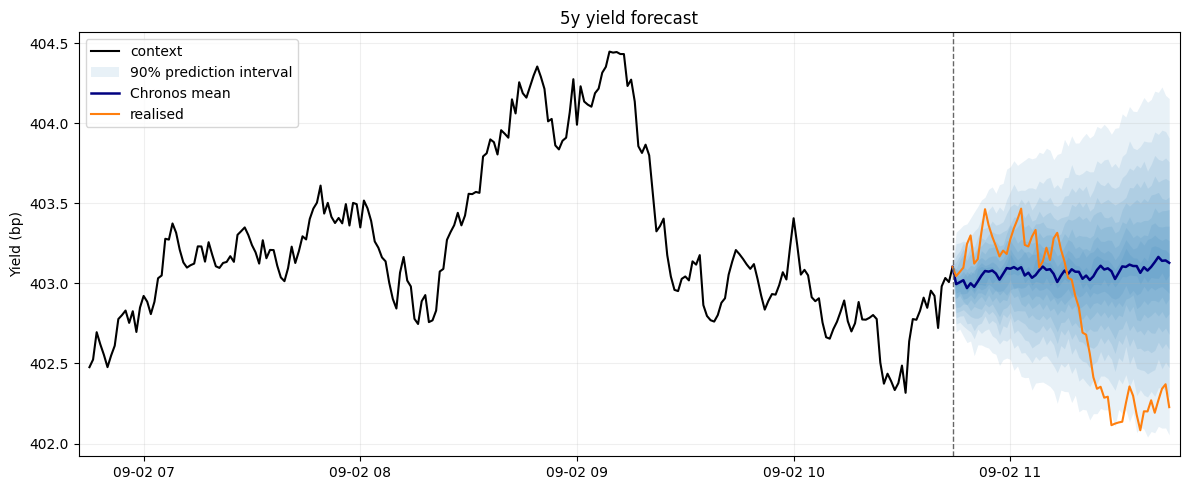

In [ ]:
plot_fan_chart(
    "5y",
    context_points=240,
    show_actual=True,
)

plt.tight_layout()
plt.show()

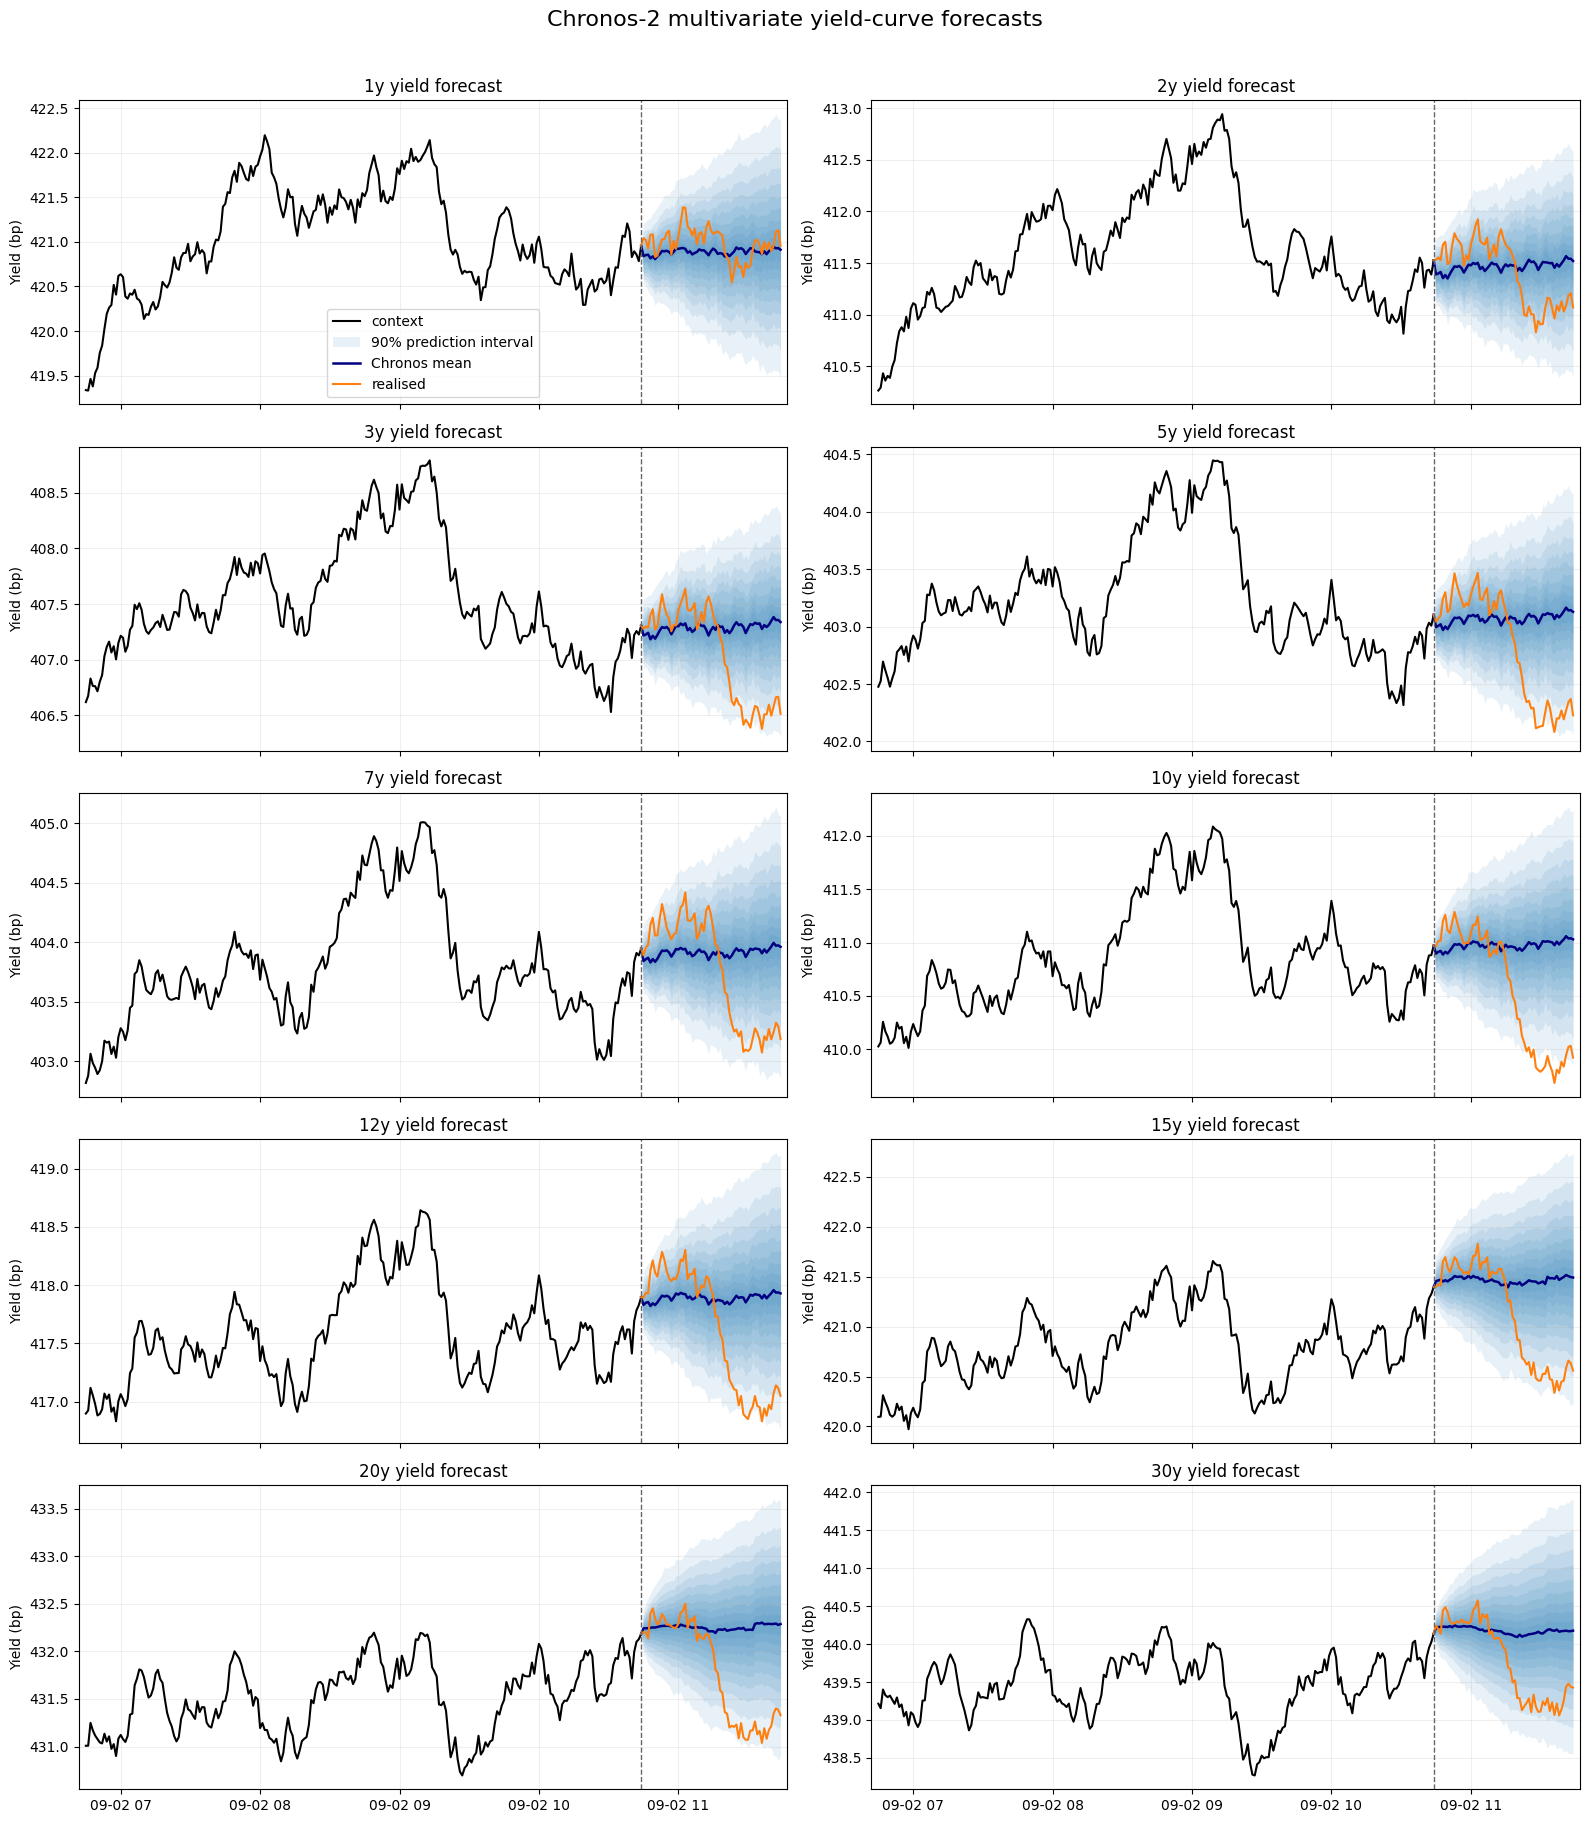

In [ ]:
fig, axes = plt.subplots(
    5,
    2,
    figsize=(16, 18),
    sharex=True,
)

for position, (tenor, ax) in enumerate(
    zip(context_df.columns, axes.flat)
):
    plot_fan_chart(
        tenor,
        context_points=240,
        show_actual=True,
        ax=ax,
        show_legend=(position == 0),
    )

fig.suptitle(
    "Chronos-2 multivariate yield-curve forecasts",
    fontsize=16,
    y=1.01,
)

fig.tight_layout()
plt.show()